<a href="https://colab.research.google.com/github/BOTTA-GOPINATH/ML_Log_Anomaly_Detector/blob/main/model1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
data = pd.read_csv("/content/sample_data/Monday-WorkingHours.pcap_ISCX.csv")

print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 529918 entries, 0 to 529917
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             529918 non-null  int64  
 1    Flow Duration                529918 non-null  int64  
 2    Total Fwd Packets            529918 non-null  int64  
 3    Total Backward Packets       529918 non-null  int64  
 4   Total Length of Fwd Packets   529918 non-null  int64  
 5    Total Length of Bwd Packets  529918 non-null  int64  
 6    Fwd Packet Length Max        529918 non-null  int64  
 7    Fwd Packet Length Min        529918 non-null  int64  
 8    Fwd Packet Length Mean       529918 non-null  float64
 9    Fwd Packet Length Std        529918 non-null  float64
 10  Bwd Packet Length Max         529918 non-null  int64  
 11   Bwd Packet Length Min        529918 non-null  int64  
 12   Bwd Packet Length Mean       529918 non-nul

In [2]:
data.columns = data.columns.str.strip()

data = data.loc[:, ~data.columns.duplicated()]

if 'Fwd Header Length.1' in data.columns:
    data.drop(columns=['Fwd Header Length.1'], inplace=True)

data.replace([np.inf, -np.inf], np.nan, inplace=True)


print("Missing values before:", data.isnull().sum().sum())

data.dropna(inplace=True)

print("Missing values after:", data.isnull().sum().sum())

Missing values before: 874
Missing values after: 0


In [3]:
nunique = data.nunique()
constant_cols = nunique[nunique == 1].index

data.drop(columns=constant_cols, inplace=True)

print("Removed constant columns:", len(constant_cols))
print("Shape after constant removal:", data.shape)

Removed constant columns: 11
Shape after constant removal: (529481, 67)


In [4]:
drop_cols = [
    'Subflow Fwd Packets',
    'Subflow Fwd Bytes',
    'Subflow Bwd Packets',
    'Subflow Bwd Bytes',
    'Fwd Packet Length Min',
    'Bwd Packet Length Max',
    'Bwd Packet Length Min',
    'Fwd Packet Length Max',
    'Fwd Header Length',
    'Bwd Header Length',
    'Fwd PSH Flags',
    'URG Flag Count',
    'ECE Flag Count',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'Fwd Packets/s',
    'Bwd Packets/s',
    'act_data_pkt_fwd',
    'min_seg_size_forward',
    'Avg Fwd Segment Size',
    'Avg Bwd Segment Size',
    'Destination Port'
]

data.drop(columns=drop_cols, inplace=True, errors='ignore')

print("Shape after manual feature removal:", data.shape)
print(data.info())

Shape after manual feature removal: (529481, 45)
<class 'pandas.core.frame.DataFrame'>
Index: 529481 entries, 0 to 529917
Data columns (total 45 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Flow Duration                529481 non-null  int64  
 1   Total Fwd Packets            529481 non-null  int64  
 2   Total Backward Packets       529481 non-null  int64  
 3   Total Length of Fwd Packets  529481 non-null  int64  
 4   Total Length of Bwd Packets  529481 non-null  int64  
 5   Fwd Packet Length Std        529481 non-null  float64
 6   Bwd Packet Length Std        529481 non-null  float64
 7   Flow Bytes/s                 529481 non-null  float64
 8   Flow Packets/s               529481 non-null  float64
 9   Flow IAT Mean                529481 non-null  float64
 10  Flow IAT Std                 529481 non-null  float64
 11  Flow IAT Max                 529481 non-null  int64  
 12  Flow IAT Min  

In [5]:
print("Original Shape:", data.shape)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(data)

X_scaled = pd.DataFrame(X_scaled, columns=data.columns)

print("Scaled Shape:", X_scaled.shape)

Original Shape: (529481, 45)
Scaled Shape: (529481, 45)


In [6]:
baseline_stats = pd.DataFrame({
    "Mean": X_scaled.mean(),
    "Std": X_scaled.std(),
    "Median": X_scaled.median(),
    "P25": X_scaled.quantile(0.25),
    "P75": X_scaled.quantile(0.75),
    "P95": X_scaled.quantile(0.95),
    "P99": X_scaled.quantile(0.99)
})

Q1 = X_scaled.quantile(0.25)
Q3 = X_scaled.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [7]:
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv

# Covariance matrix
cov_matrix = np.cov(X_scaled.T)

# Inverse covariance
inv_cov_matrix = inv(cov_matrix)

# Mean vector
mean_vector = X_scaled.mean().values


def mahalanobis_distance(row):
    return mahalanobis(row, mean_vector, inv_cov_matrix)


print("Calculating anomaly score...")

X_scaled["anomaly_score"] = X_scaled.apply(mahalanobis_distance, axis=1)

X_scaled["anomaly_score"].describe()

Calculating anomaly score...


,anomaly_score
count,529481.000000
mean,4.320208
std,5.131838
min,1.254719
25%,1.783249
50%,2.919870
75%,4.792475
max,674.798769


In [8]:
threshold = X_scaled["anomaly_score"].quantile(0.95)

X_scaled["anomaly_label"] = (X_scaled["anomaly_score"] > threshold).astype(int)

print(X_scaled["anomaly_label"].value_counts())

anomaly_label
0    503007
1     26474
Name: count, dtype: int64


In [9]:
corr_matrix = data.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Highly correlated features to drop:", len(to_drop))
print(to_drop)

Highly correlated features to drop: 15
['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Max', 'Bwd IAT Min', 'Packet Length Std', 'Packet Length Variance', 'Average Packet Size', 'Idle Mean', 'Idle Max', 'Idle Min']


In [10]:
data_filtered = data.drop(columns=to_drop)

print("Shape after correlation filtering:", data_filtered.shape)

Shape after correlation filtering: (529481, 30)


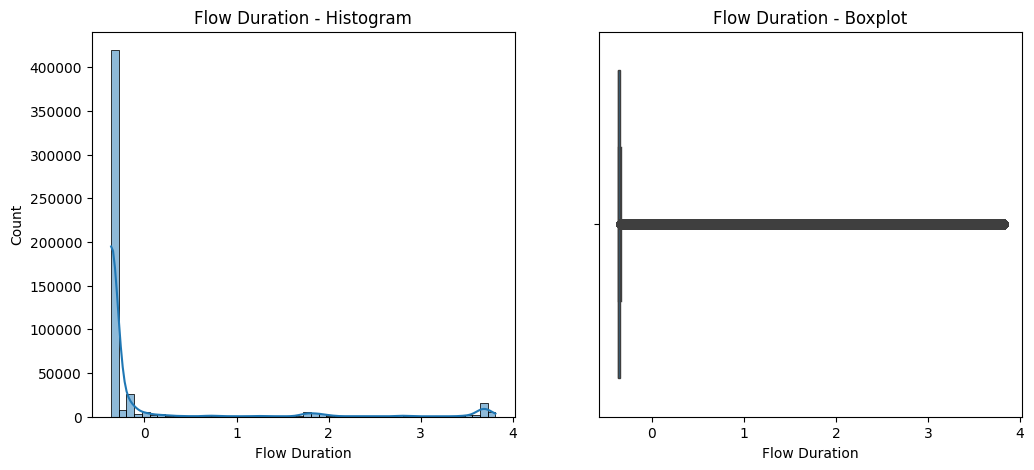

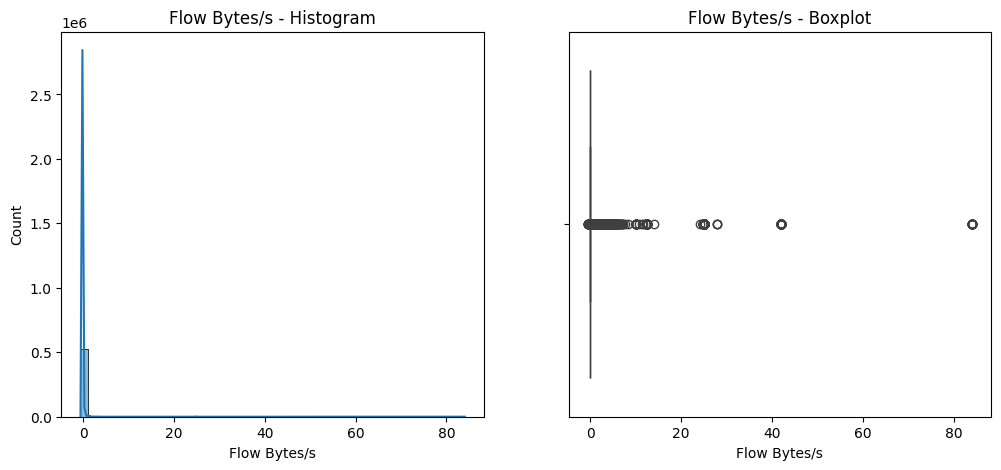

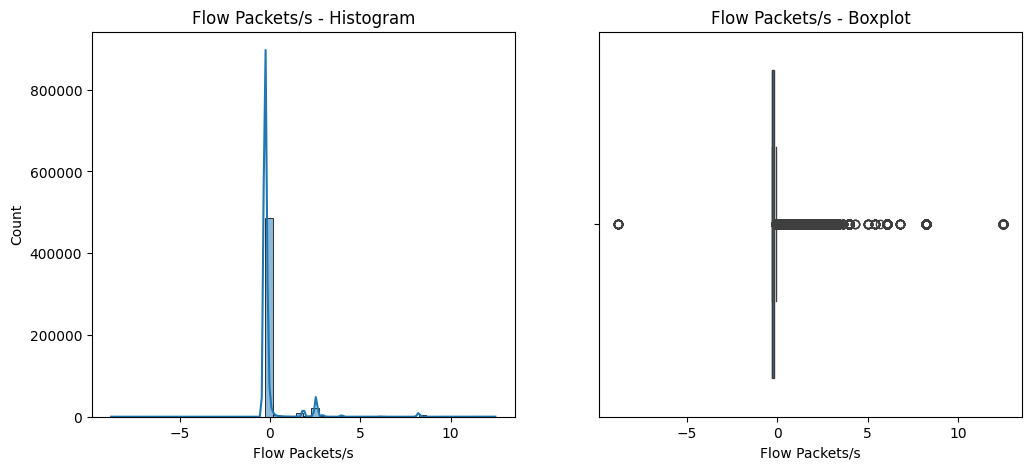

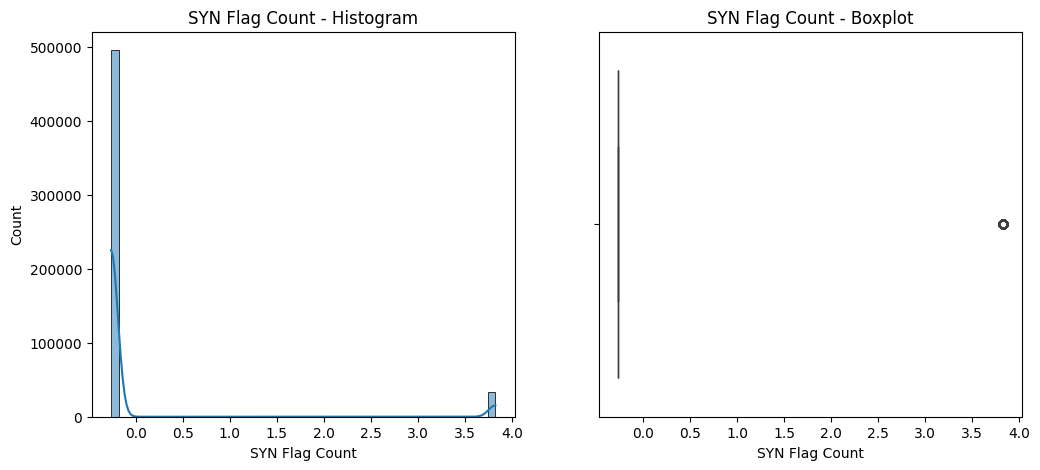

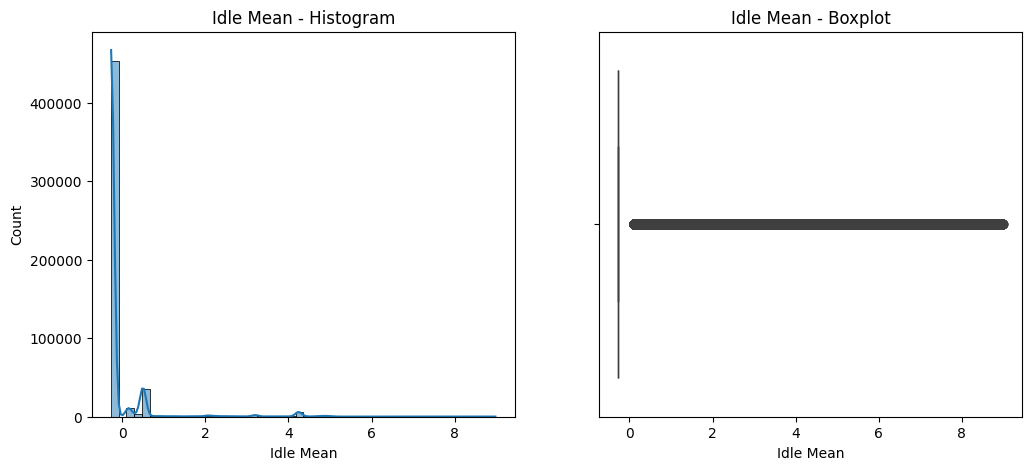

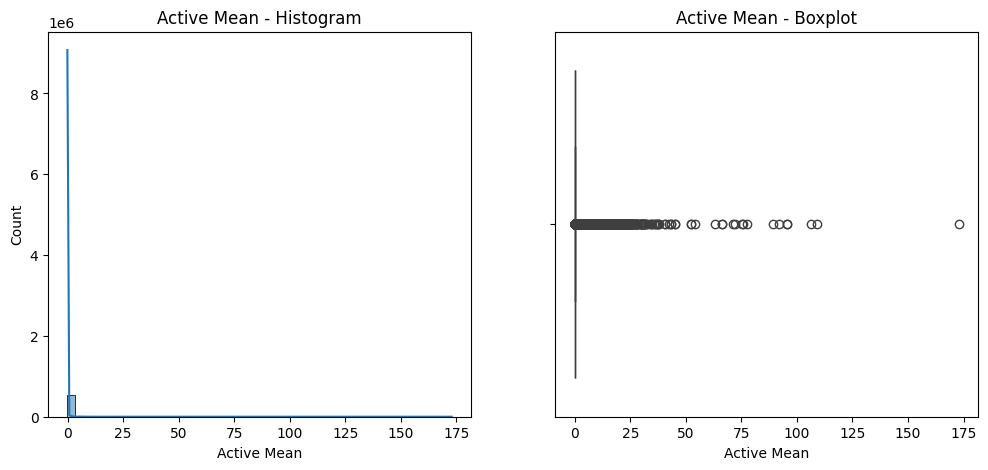

In [11]:
features = [
    "Flow Duration",
    "Flow Bytes/s",
    "Flow Packets/s",
    "SYN Flag Count",
    "Idle Mean",
    "Active Mean"
]

for feature in features:
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.histplot(X_scaled[feature], bins=50, kde=True)
    plt.title(f"{feature} - Histogram")
    plt.subplot(1,2,2)
    sns.boxplot(x=X_scaled[feature])
    plt.title(f"{feature} - Boxplot")
    plt.show()

In [12]:
scaler = StandardScaler()
X_scaled_new = scaler.fit_transform(data_filtered)
X_scaled_new = pd.DataFrame(X_scaled_new, columns=data_filtered.columns)

print("New scaled shape:", X_scaled_new.shape)

New scaled shape: (529481, 30)


In [13]:
cov_matrix = np.cov(X_scaled_new.T)
print("Covariance shape:", cov_matrix.shape)

Covariance shape: (30, 30)


In [14]:
inv_cov_matrix = np.linalg.pinv(cov_matrix)

In [15]:
from scipy.spatial.distance import mahalanobis

mean_vector = X_scaled_new.mean().values

def mahalanobis_distance(row):
    return mahalanobis(row, mean_vector, inv_cov_matrix)

print("Recomputing anomaly scores...")

X_scaled_new["anomaly_score"] = X_scaled_new.apply(
    mahalanobis_distance, axis=1
)

print(X_scaled_new["anomaly_score"].describe())

Recomputing anomaly scores...
count    529481.000000
mean          3.701455
std           4.037228
min           1.183055
25%           1.435509
50%           2.594788
75%           4.424495
max         309.440808
Name: anomaly_score, dtype: float64


we need to test multiple thresholds

In [16]:
for q in [0.99, 0.995, 0.999]:
    threshold = X_scaled_new["anomaly_score"].quantile(q)
    anomalies = (X_scaled_new["anomaly_score"] > threshold).sum()
    print(q, anomalies)

0.99 5295
0.995 2648
0.999 530


In [17]:
# Create anomaly threshold
threshold = X_scaled_new["anomaly_score"].quantile(0.995)

# Create anomaly label
X_scaled_new["anomaly_label"] = (
    X_scaled_new["anomaly_score"] > threshold
).astype(int)

print("Anomaly Threshold:", threshold)
print(X_scaled_new["anomaly_label"].value_counts())

Anomaly Threshold: 22.15048243912132
anomaly_label
0    526833
1      2648
Name: count, dtype: int64


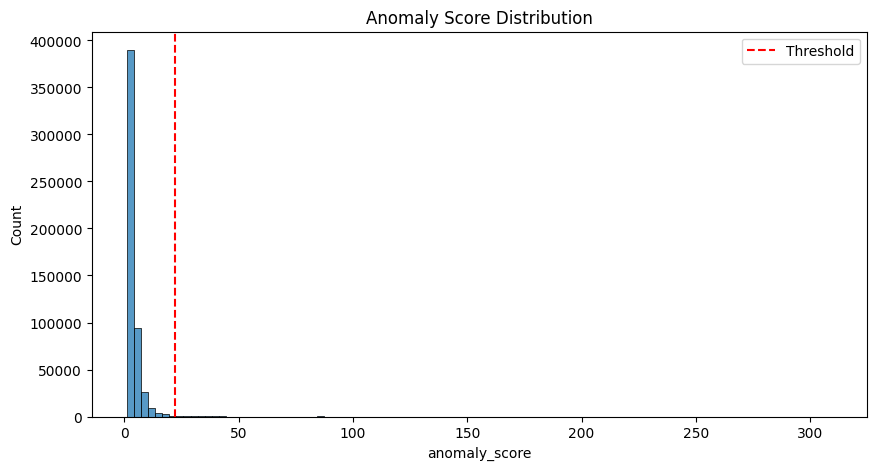

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(X_scaled_new["anomaly_score"], bins=100)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.legend()
plt.title("Anomaly Score Distribution")
plt.show()

In [19]:
top_anomalies = X_scaled_new.sort_values(
    "anomaly_score", ascending=False
).head(20)

print(top_anomalies)

        Flow Duration  Total Fwd Packets  Total Length of Fwd Packets  \
11451        0.166018           0.207893                   145.830311   
7367         3.810621         216.391025                   186.521104   
45022        3.502181           0.112684                     3.278372   
4755         3.810622         246.139672                   212.294197   
17342        3.810603         244.906445                   206.437529   
17811        3.810416         243.942042                   206.620159   
20490        3.810615         239.829047                   203.404239   
430428      -0.360389          -0.010526                    -0.084550   
6062         3.810621         235.302737                   203.256434   
18968        3.807940         235.114560                   199.882921   
8357         3.687836           0.942676                     9.851115   
32457        2.237026         214.631353                   167.117422   
22703        3.435244         206.118619           

Text(0.5, 1.0, 'Anomaly Score Distribution')

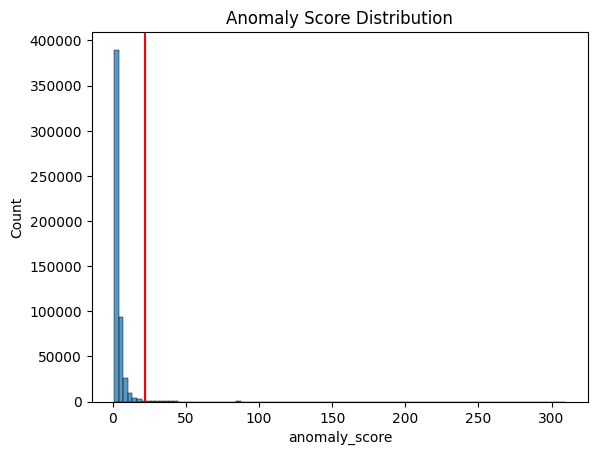

In [20]:
sns.histplot(X_scaled_new["anomaly_score"], bins=100)
plt.axvline(threshold, color="red")
plt.title("Anomaly Score Distribution")

In [21]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.005,
    random_state=42
)

iso_pred = iso.fit_predict(X_scaled_new.drop(columns=["anomaly_score"]))

X_scaled_new["iso_label"] = (iso_pred == -1).astype(int)

In [22]:
overlap = (
    (X_scaled_new["anomaly_label"] == 1) &
    (X_scaled_new["iso_label"] == 1)
).sum()

print("Overlap anomalies:", overlap)

Overlap anomalies: 1059


Adding the final dataset to a file

In [23]:
X_scaled_new.to_csv("/content/sample_data/anomaly_results.csv", index=False)

print("Dataset saved as anomaly_results.csv")

Dataset saved as anomaly_results.csv


In [24]:
anomalies = X_scaled_new[X_scaled_new["anomaly_label"] == 1]

print("Total Mahalanobis anomalies:", len(anomalies))

anomalies.to_csv("/content/sample_data/anomalies_only.csv", index=False)

print("Anomaly dataset saved as anomalies_only.csv")

Total Mahalanobis anomalies: 2648
Anomaly dataset saved as anomalies_only.csv


lets compare the models

In [25]:
mahalanobis_anomalies = X_scaled_new["anomaly_label"].sum()
iso_anomalies = X_scaled_new["iso_label"].sum()

overlap_anomalies = (
    (X_scaled_new["anomaly_label"] == 1) &
    (X_scaled_new["iso_label"] == 1)
).sum()

summary = {
    "Total Records": len(X_scaled_new),
    "Mahalanobis Anomalies": mahalanobis_anomalies,
    "Isolation Forest Anomalies": iso_anomalies,
    "Overlap Anomalies": overlap_anomalies
}

print("\nModel Comparison Summary")
for k,v in summary.items():
    print(f"{k}: {v}")


Model Comparison Summary
Total Records: 529481
Mahalanobis Anomalies: 2648
Isolation Forest Anomalies: 2648
Overlap Anomalies: 1059


In [26]:
summary_df = pd.DataFrame([summary])
summary_df.to_csv("/content/sample_data/model_comparison_summary.csv", index=False)
print("summary is saved as model_comparison_summary.csv")

summary is saved as model_comparison_summary.csv


In [27]:
# Load the original CSV completely first to handle potential whitespace in column names
raw_labels_df = pd.read_csv(
    "/content/sample_data/Monday-WorkingHours.pcap_ISCX.csv"
)

# Strip column names as done for the main dataframe to ensure 'Label' is correctly identified
raw_labels_df.columns = raw_labels_df.columns.str.strip()

# Now, retrieve the 'Label' column
if 'Label' in raw_labels_df.columns:
    original_labels = raw_labels_df['Label']
else:
    raise ValueError("The 'Label' column was not found in the original CSV even after stripping column names.")

# Add Label column to anomaly dataset, ensuring alignment with the rows that were kept in X_scaled_new
X_scaled_new["Label"] = original_labels.loc[X_scaled_new.index]

# Check
print(X_scaled_new[["Label","anomaly_label"]].head())

    Label  anomaly_label
0  BENIGN              0
1  BENIGN              0
2  BENIGN              0
3  BENIGN              0
4  BENIGN              0


In [28]:
print(X_scaled_new)

        Flow Duration  Total Fwd Packets  Total Length of Fwd Packets  \
0           -0.361510          -0.009406                    -0.083587   
1           -0.361510          -0.009406                    -0.083587   
2           -0.361510          -0.009406                    -0.083587   
3           -0.361510          -0.009406                    -0.083587   
4           -0.361510          -0.009406                    -0.083587   
...               ...                ...                          ...   
529476      -0.360859          -0.010526                    -0.084550   
529477      -0.359397          -0.009406                    -0.072674   
529478      -0.361505          -0.009406                    -0.075242   
529479      -0.361505          -0.009406                    -0.072674   
529480      -0.361510          -0.010526                    -0.085513   

        Fwd Packet Length Std  Bwd Packet Length Std  Flow Bytes/s  \
0                   -0.392281              -0.476263 

In [29]:
df = pd.read_csv("/content/sample_data/anomaly_results.csv")

# Check dataset
print(df.shape)
print(df.head())

(529481, 33)
   Flow Duration  Total Fwd Packets  Total Length of Fwd Packets  \
0       -0.36151          -0.009406                    -0.083587   
1       -0.36151          -0.009406                    -0.083587   
2       -0.36151          -0.009406                    -0.083587   
3       -0.36151          -0.009406                    -0.083587   
4       -0.36151          -0.009406                    -0.083587   

   Fwd Packet Length Std  Bwd Packet Length Std  Flow Bytes/s  Flow Packets/s  \
0              -0.392281              -0.476263      0.056308        1.844131   
1              -0.392281              -0.476263      0.421751        8.221354   
2              -0.392281              -0.476263      0.421751        8.221354   
3              -0.392281              -0.476263      0.421751        8.221354   
4              -0.392281              -0.476263      0.096913        2.552712   

   Flow IAT Mean  Flow IAT Std  Flow IAT Max  ...  Init_Win_bytes_forward  \
0      -0.2092

In [30]:
print(df.columns)

Index(['Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets',
       'Fwd Packet Length Std', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Bwd IAT Std',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'Down/Up Ratio', 'Init_Win_bytes_forward',
       'Init_Win_bytes_backward', 'Active Mean', 'Active Std', 'Active Max',
       'Active Min', 'Idle Std', 'anomaly_score', 'anomaly_label',
       'iso_label'],
      dtype='object')


In [31]:
print("Mahalanobis anomalies:")
print(df["anomaly_label"].value_counts())

print("\nIsolation Forest anomalies:")
print(df["iso_label"].value_counts())

Mahalanobis anomalies:
anomaly_label
0    526833
1      2648
Name: count, dtype: int64

Isolation Forest anomalies:
iso_label
0    526833
1      2648
Name: count, dtype: int64


In [32]:
anomalies = df[df["anomaly_label"] == 1]
print(anomalies.head())

     Flow Duration  Total Fwd Packets  Total Length of Fwd Packets  \
72        3.800862           0.247096                    -0.085513   
119       3.601217           0.287419                     3.195884   
125       1.969226          -0.002686                    -0.023887   
126       2.004267          -0.002686                    -0.023887   
128       2.074055          -0.001565                    -0.016184   

     Fwd Packet Length Std  Bwd Packet Length Std  Flow Bytes/s  \
72               -0.392281              -0.476263     -0.065506   
119              -0.091122              -0.476263     -0.065499   
125              -0.392281              -0.476263     -0.065506   
126              -0.392281              -0.476263     -0.065506   
128              -0.392281              -0.476263     -0.065506   

     Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Max  ...  \
72        -0.281602      -0.107473      0.120933      1.166333  ...   
119       -0.281600      -0.125465

In [33]:
original_df = pd.read_csv("/content/sample_data/Monday-WorkingHours.pcap_ISCX.csv")

# Remove whitespace from column names
original_df.columns = original_df.columns.str.strip()

# Extract Label column
labels = original_df["Label"]

# Add Label column to anomaly dataset
df["Label"] = labels.loc[df.index]

# Check
print(df[["Label","anomaly_label","iso_label"]].head())

    Label  anomaly_label  iso_label
0  BENIGN              0          0
1  BENIGN              0          0
2  BENIGN              0          0
3  BENIGN              0          0
4  BENIGN              0          0


In [34]:
df.to_csv("/content/sample_data/anomaly_results_with_labels.csv", index=False)
print("Dataset saved successfully")

Dataset saved successfully
